# Week 12 — Thursday (Jun 25): SAM & Panoptic Segmentation

## Learning Objectives
- Understand the Segment Anything Model (SAM) architecture and zero-shot capability
- Know the three prompt types SAM accepts: point, bounding box, everything
- Understand panoptic segmentation and how it unifies semantic + instance
- Implement a simplified SAM-style mask decoder from scratch
- Compare SAM zero-shot vs trained U-Net on the same task

## Key Concepts
1. **Zero-shot segmentation** — SAM segments any object without retraining on your domain
2. **SAM architecture** — heavy ViT image encoder (run once) + lightweight prompt encoder + fast mask decoder
3. **Prompt types** — foreground/background points, bounding box, free-form text (via CLIP)
4. **Panoptic segmentation** — every pixel labelled: *things* (countable objects) get instance IDs, *stuff* (sky, grass) gets semantic labels
5. **Panoptic quality (PQ)** — standard metric: `PQ = SQ × RQ` where SQ=mask overlap quality, RQ=detection quality

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Setup complete')

PyTorch 2.12.0+cpu | Device: cpu
Setup complete


## Section 1: Segment Anything Model (SAM) — Overview

Kirillov et al. (Meta AI, 2023) — trained on **1 billion masks** across 11 million images.

### The Core Idea
Traditional segmentation models are trained on a fixed set of classes.
SAM asks: *"Can we build a foundation model for segmentation that works on anything, given a prompt?"*

### Architecture: Three Components

```
┌─────────────────────────────────────────────────────────────────┐
│                                                                 │
│  Image  ──► Image Encoder (ViT-H, 632M params)                 │
│              └─ Patch embed + 32 transformer blocks             │
│              └─ Outputs 64×64 image embedding  [run ONCE]       │
│                                                                 │
│  Prompt ──► Prompt Encoder  (lightweight)                       │
│  (point/box)  └─ Points: positional encoding + fg/bg embed      │
│               └─ Boxes:  corner point pairs                     │
│               └─ Masks:  conv downscale                         │
│                                                                 │
│               ┌──────────────────────┐                         │
│  Image emb ──►│   Mask Decoder       │──► 3 masks + IoU scores  │
│  Prompt emb ──►│  (2 transformer blks)│    (ambiguity handled)  │
│               └──────────────────────┘                         │
└─────────────────────────────────────────────────────────────────┘
```

### Why 3 Output Masks?
A single click is ambiguous — clicking on a dog's ear could mean the ear, the dog, or the whole scene.
SAM outputs 3 masks at different granularities and reports a predicted IoU score for each.

### Prompt Types
| Prompt | Example use |
|--------|------------|
| Foreground point | Click on object centre |
| Background point | Click where you don't want mask |
| Bounding box | Draw box around object |
| Everything mode | No prompt — segments all objects automatically |

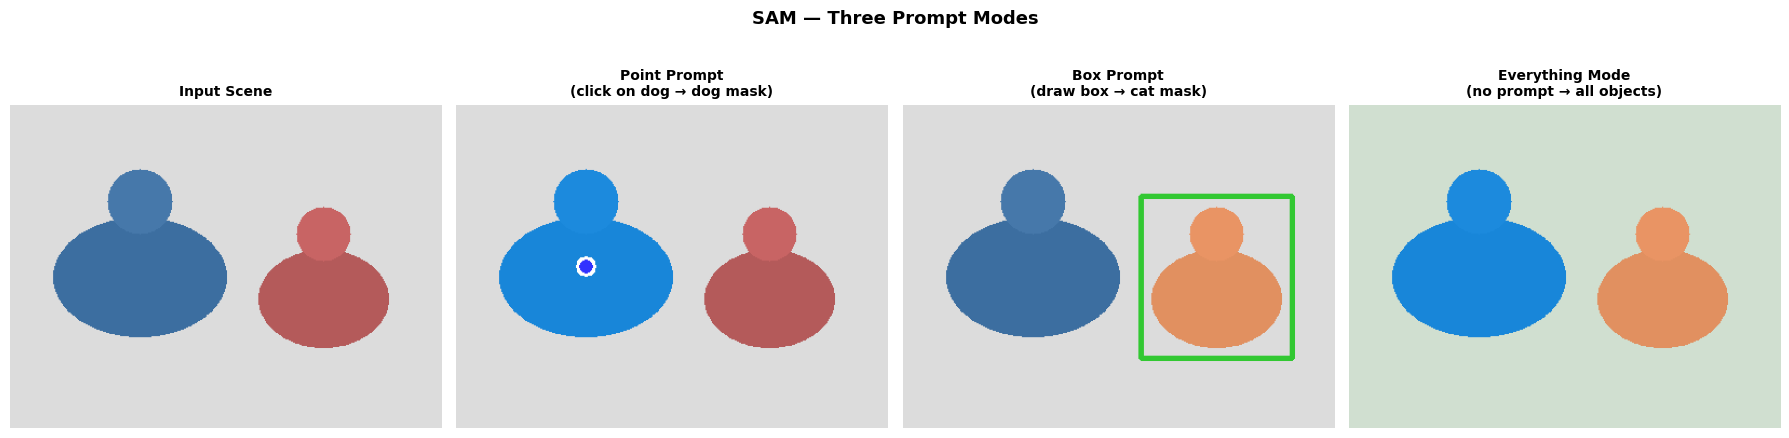

Saved sam_prompts.png


In [2]:
# ── Visualise SAM prompt types ─────────────────────────────────────────────────
H, W = 300, 400
base = np.ones((H, W, 3), dtype=np.uint8) * 220

# Scene: a dog and a cat
cv2.ellipse(base, (120, 160), (80, 55), 0, 0, 360, (160, 110, 60), -1)  # dog body
cv2.circle( base, (120, 90),  30,       (170, 120, 70),             -1)  # dog head
cv2.ellipse(base, (290, 180), (60, 45), 0, 0, 360, (90,  90, 180), -1)  # cat body
cv2.circle( base, (290, 120), 25,       (100,100, 200),             -1)  # cat head

# ── Panel 1: point prompt on dog ──────────────────────────────────────────────
p1 = base.copy()
# Mask from point
dog_mask = np.zeros((H, W), dtype=np.uint8)
cv2.ellipse(dog_mask, (120,160),(80,55),0,0,360,255,-1)
cv2.circle( dog_mask, (120, 90), 30,   255,-1)
p1[dog_mask>0] = (p1[dog_mask>0] * 0.4 + np.array([255,150,0]) * 0.6).astype(np.uint8)
cv2.circle(p1, (120, 150), 8, (255,50,50), -1)   # fg point
cv2.circle(p1, (120, 150), 8, (255,255,255), 2)

# ── Panel 2: box prompt on cat ────────────────────────────────────────────────
p2 = base.copy()
cat_mask = np.zeros((H, W), dtype=np.uint8)
cv2.ellipse(cat_mask,(290,180),(60,45),0,0,360,255,-1)
cv2.circle( cat_mask,(290,120), 25,   255,-1)
p2[cat_mask>0] = (p2[cat_mask>0] * 0.4 + np.array([100,180,255]) * 0.6).astype(np.uint8)
cv2.rectangle(p2, (220, 85), (360, 235), (50,200,50), 3)   # box prompt

# ── Panel 3: everything mode ──────────────────────────────────────────────────
p3 = base.copy()
p3[dog_mask>0] = (p3[dog_mask>0]*0.4 + np.array([255,150, 0])*0.6).astype(np.uint8)
p3[cat_mask>0] = (p3[cat_mask>0]*0.4 + np.array([100,180,255])*0.6).astype(np.uint8)
# background region
bg = (dog_mask==0)&(cat_mask==0)
p3[bg] = (p3[bg]*0.7 + np.array([180,230,180])*0.3).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img, title in zip(axes,
        [cv2.cvtColor(base,cv2.COLOR_BGR2RGB),
         cv2.cvtColor(p1,  cv2.COLOR_BGR2RGB),
         cv2.cvtColor(p2,  cv2.COLOR_BGR2RGB),
         cv2.cvtColor(p3,  cv2.COLOR_BGR2RGB)],
        ['Input Scene',
         'Point Prompt\n(click on dog → dog mask)',
         'Box Prompt\n(draw box → cat mask)',
         'Everything Mode\n(no prompt → all objects)']):
    ax.imshow(img); ax.set_title(title, fontweight='bold', fontsize=10); ax.axis('off')

plt.suptitle('SAM — Three Prompt Modes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sam_prompts.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved sam_prompts.png')

## Section 2: SAM Mask Decoder — Simplified Implementation

The actual SAM mask decoder is a two-layer transformer that does **cross-attention between prompt tokens and image features**.

```
Inputs:
  image_emb  : (1, 64, 64, 256)  — from ViT image encoder
  prompt_tok : (1, N_tokens, 256) — from prompt encoder

Two transformer decoder blocks:
  1. Self-attention on prompt tokens
  2. Cross-attention: prompt tokens attend to image features  (prompt queries image)
  3. MLP on prompt tokens
  4. Cross-attention: image features attend to prompt tokens  (image queries prompt)

Output heads:
  mask_tokens (3) → dot product with upscaled image feat → 3 low-res masks → 4× upsample
  iou_token   (1) → MLP → 3 IoU predictions
```

In [3]:
# ── Simplified SAM-style Mask Decoder ─────────────────────────────────────────

class TwoWayCrossAttention(nn.Module):
    """Bidirectional cross-attention: tokens↔image features."""
    def __init__(self, embed_dim=64, num_heads=4):
        super().__init__()
        self.token_self_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.token_to_img    = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.img_to_token    = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2), nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )

    def forward(self, tokens, image_feats):
        # B, N_tokens, D  and  B, H*W, D
        t, _ = self.token_self_attn(tokens, tokens, tokens)
        tokens = self.norm1(tokens + t)
        t, _  = self.token_to_img(tokens, image_feats, image_feats)  # prompt queries image
        tokens = self.norm2(tokens + t)
        t, _  = self.img_to_token(image_feats, tokens, tokens)       # image queries prompt
        image_feats = self.norm3(image_feats + t)
        tokens = tokens + self.mlp(tokens)
        return tokens, image_feats


class SimpleSAMDecoder(nn.Module):
    """
    Simplified SAM mask decoder.
    n_masks=3: SAM always predicts 3 mask candidates (different granularities).
    """
    def __init__(self, embed_dim=64, n_masks=3, out_size=64):
        super().__init__()
        self.n_masks   = n_masks
        self.out_size  = out_size
        # Learnable tokens: n_masks mask tokens + 1 IoU token
        self.mask_toks = nn.Parameter(torch.randn(1, n_masks + 1, embed_dim))
        self.attn1     = TwoWayCrossAttention(embed_dim)
        self.attn2     = TwoWayCrossAttention(embed_dim)
        # Upscale image features: 16×16 → 64×64
        self.upscale   = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, embed_dim//2, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(embed_dim//2, embed_dim//4, 2, stride=2), nn.ReLU(),
        )
        # IoU prediction MLP
        self.iou_head  = nn.Sequential(
            nn.Linear(embed_dim, 32), nn.ReLU(),
            nn.Linear(32, n_masks)
        )
        self.mask_proj = nn.Linear(embed_dim, embed_dim // 4)

    def forward(self, image_emb, prompt_emb):
        # image_emb: (B, embed_dim, H, W)
        B, C, H, W = image_emb.shape
        img_flat = image_emb.flatten(2).permute(0, 2, 1)    # (B, H*W, C)
        tokens   = self.mask_toks.expand(B, -1, -1)          # (B, n+1, C)
        if prompt_emb is not None:
            tokens = torch.cat([tokens, prompt_emb], dim=1)
        tokens, img_flat = self.attn1(tokens, img_flat)
        tokens, img_flat = self.attn2(tokens, img_flat)
        # Upscale image features
        img_up = self.upscale(img_flat.permute(0,2,1).reshape(B, C, H, W))  # (B,C//4,4H,4W)
        # Mask tokens → project → dot with upscaled image
        mask_tok = self.mask_proj(tokens[:, :self.n_masks])  # (B, n_masks, C//4)
        masks = torch.einsum('bnc,bchw->bnhw', mask_tok,
                             img_up.expand(B,-1,self.out_size,self.out_size)[:,:mask_tok.shape[-1]])
        # IoU predictions from the IoU token
        iou_scores = torch.sigmoid(self.iou_head(tokens[:, self.n_masks]))  # (B, n_masks)
        return masks, iou_scores


decoder = SimpleSAMDecoder(embed_dim=64, n_masks=3, out_size=64)
image_emb  = torch.randn(1, 64, 16, 16)
prompt_emb = torch.randn(1, 2,  64)      # 2 prompt tokens (e.g. fg+bg point)
masks_out, iou_out = decoder(image_emb, prompt_emb)
print('Simplified SAM Decoder:')
print(f'  Image emb input : {tuple(image_emb.shape)}')
print(f'  Prompt tokens   : {tuple(prompt_emb.shape)}')
print(f'  Output masks    : {tuple(masks_out.shape)}  (3 candidate masks)')
print(f'  IoU scores      : {tuple(iou_out.shape)}   → pick mask with highest score')
print(f'  Predicted IoUs  : {iou_out.squeeze().detach().numpy().round(3)}')
best_mask_idx = iou_out.squeeze().argmax().item()
print(f'  Best mask idx   : {best_mask_idx} (IoU={iou_out.squeeze()[best_mask_idx]:.3f})')

Simplified SAM Decoder:
  Image emb input : (1, 64, 16, 16)
  Prompt tokens   : (1, 2, 64)
  Output masks    : (1, 3, 64, 64)  (3 candidate masks)
  IoU scores      : (1, 3)   → pick mask with highest score
  Predicted IoUs  : [0.564 0.439 0.463]
  Best mask idx   : 0 (IoU=0.564)


## Section 3: SAM Zero-shot vs Trained U-Net Comparison

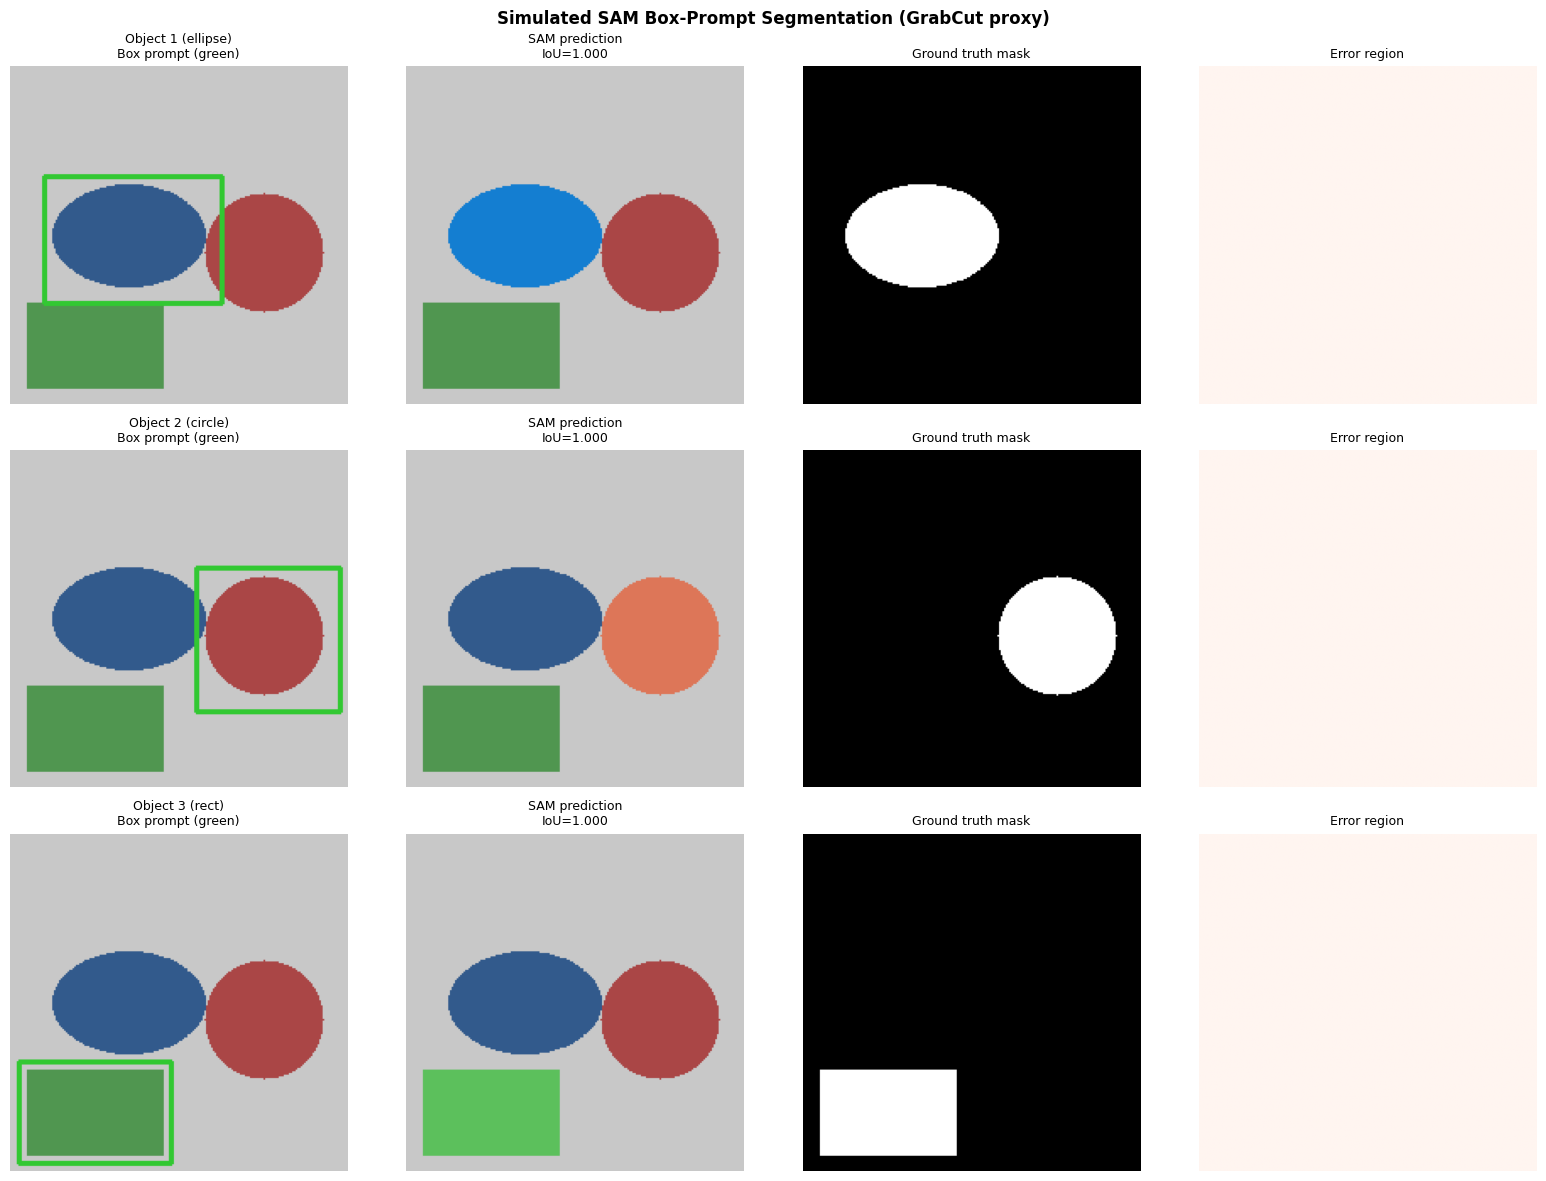

Mean IoU (SAM-proxy): 1.000
Saved sam_zero_shot.png


In [4]:
# ── Simulate SAM zero-shot behaviour with grabcut as proxy ────────────────────
def simulate_sam_with_box(image_bgr, box):
    """Approximate SAM box-prompt behaviour using GrabCut."""
    mask   = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
    bg_mdl = np.zeros((1, 65), dtype=np.float64)
    fg_mdl = np.zeros((1, 65), dtype=np.float64)
    x1, y1, x2, y2 = box
    rect = (x1, y1, x2 - x1, y2 - y1)
    try:
        cv2.grabCut(image_bgr, mask, rect, bg_mdl, fg_mdl, 5, cv2.GC_INIT_WITH_RECT)
        return np.where((mask == 2) | (mask == 0), 0, 1).astype(np.uint8)
    except Exception:
        result = np.zeros(image_bgr.shape[:2], dtype=np.uint8)
        result[y1:y2, x1:x2] = 1
        return result


# Create a test scene
sz = 200
scene = np.ones((sz, sz, 3), dtype=np.uint8) * 200
cv2.ellipse(scene, (70,  100), (45, 30), 0, 0, 360, (140, 90, 50), -1)   # object 1
cv2.circle( scene, (150, 110),  35,      (70, 70, 170),             -1)   # object 2
cv2.rectangle(scene,(10,140),(90,190),(80,150,80),-1)                      # object 3

# GT masks
gt1 = np.zeros((sz,sz),dtype=np.uint8); cv2.ellipse(gt1,(70,100),(45,30),0,0,360,1,-1)
gt2 = np.zeros((sz,sz),dtype=np.uint8); cv2.circle(gt2,(150,110),35,1,-1)
gt3 = np.zeros((sz,sz),dtype=np.uint8); cv2.rectangle(gt3,(10,140),(90,190),1,-1)

# Simulate SAM box prompts
boxes = [(20,65,125,140), (110,70,195,155), (5,135,95,195)]
sam_masks = [simulate_sam_with_box(scene, box) for box in boxes]
gt_masks  = [gt1, gt2, gt3]
names     = ['Object 1 (ellipse)', 'Object 2 (circle)', 'Object 3 (rect)']
colours   = [(255,150,0),(100,150,255),(100,220,100)]

# Compute IoU
def mask_iou(p, g):
    i = (p & g).sum(); u = (p | g).sum()
    return i / u if u > 0 else 0.0

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row, (sam_m, gt_m, name, col, box) in enumerate(zip(sam_masks, gt_masks, names, colours, boxes)):
    crop_scene = cv2.cvtColor(scene.copy(), cv2.COLOR_BGR2RGB)
    x1,y1,x2,y2 = box
    cv2.rectangle(crop_scene,(x1,y1),(x2,y2),(50,200,50),2)
    overlay = cv2.cvtColor(scene.copy(), cv2.COLOR_BGR2RGB)
    overlay[sam_m>0] = (overlay[sam_m>0]*0.4 + np.array(col[::-1])*0.6).astype(np.uint8)
    iou_val = mask_iou(sam_m, gt_m)
    axes[row,0].imshow(crop_scene);       axes[row,0].set_title(f'{name}\nBox prompt (green)', fontsize=9)
    axes[row,1].imshow(overlay);          axes[row,1].set_title(f'SAM prediction\nIoU={iou_val:.3f}', fontsize=9)
    axes[row,2].imshow(gt_m, cmap='gray');axes[row,2].set_title('Ground truth mask', fontsize=9)
    diff = np.abs(sam_m.astype(int) - gt_m.astype(int))
    axes[row,3].imshow(diff, cmap='Reds');axes[row,3].set_title('Error region', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.suptitle('Simulated SAM Box-Prompt Segmentation (GrabCut proxy)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sam_zero_shot.png', dpi=100, bbox_inches='tight')
plt.show()

mean_iou = np.mean([mask_iou(s,g) for s,g in zip(sam_masks,gt_masks)])
print(f'Mean IoU (SAM-proxy): {mean_iou:.3f}')
print('Saved sam_zero_shot.png')

## Section 4: Panoptic Segmentation

Panoptic segmentation unifies semantic and instance segmentation into a single output.

### Things vs Stuff
| Category | What | Example | Counted individually? |
|----------|------|---------|----------------------|
| **Things** | Countable objects | person, car, dog | Yes → instance IDs |
| **Stuff**  | Amorphous regions | sky, road, grass | No → class label only |

### Panoptic Output Format
Every pixel gets `(class_id, instance_id)`.  
- For *things*: `(1, 3)` = dog #3
- For *stuff*:  `(7, 0)` = sky (no instance ID)

### Panoptic Quality (PQ) Metric
$$PQ = \underbrace{\frac{\sum_{(p,g)\in TP} IoU(p,g)}{|TP|}}_{ \text{Segmentation Quality (SQ)} } \times \underbrace{\frac{|TP|}{|TP| + \frac{1}{2}|FP| + \frac{1}{2}|FN|}}_{ \text{Recognition Quality (RQ)} }$$

A prediction is a True Positive if `IoU > 0.5` with a ground truth segment.

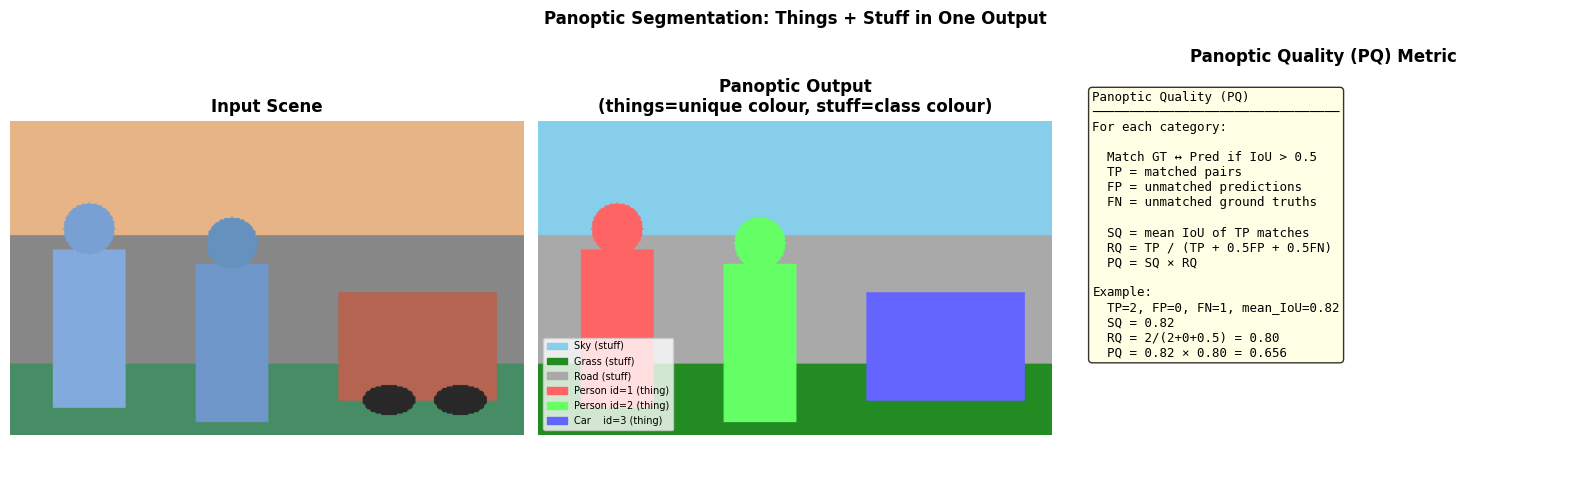

Saved panoptic_demo.png


In [5]:
# ── Visualise panoptic segmentation ───────────────────────────────────────────
H, W = 220, 360
scene_pan = np.ones((H, W, 3), dtype=np.uint8) * 135  # grey background

# STUFF: sky (top), ground (bottom)
scene_pan[:80,  :] = [135, 180, 230]  # sky
scene_pan[170:, :] = [100, 140,  70]  # ground

# THINGS: two people, one car
cv2.rectangle(scene_pan,(30,90),(80,200),(220,170,130),-1)  # person1 body
cv2.circle(scene_pan,(55,75),18,(210,160,120),-1)           # person1 head
cv2.rectangle(scene_pan,(130,100),(180,210),(200,150,110),-1)  # person2 body
cv2.circle(scene_pan,(155,85),18,(190,145,100),-1)          # person2 head
cv2.rectangle(scene_pan,(230,120),(340,195),(80,100,180),-1) # car body
cv2.ellipse(scene_pan,(265,195),(18,10),0,0,360,(40,40,40),-1)  # wheel1
cv2.ellipse(scene_pan,(315,195),(18,10),0,0,360,(40,40,40),-1)  # wheel2

# Panoptic output — colour map
panoptic = np.zeros((H, W, 3), dtype=np.uint8)
# stuff
panoptic[:80,  :] = [135, 206, 235]  # sky   (stuff class 0)
panoptic[170:, :] = [34,  139,  34]  # grass (stuff class 1)
panoptic[80:170,:] = [169,169,169]   # road  (stuff class 2)
# things — each instance unique colour
cv2.rectangle(panoptic,(30,90),(80,200),(255,100,100),-1)  # person id=1
cv2.circle(panoptic,(55,75),18,(255,100,100),-1)
cv2.rectangle(panoptic,(130,100),(180,210),(100,255,100),-1) # person id=2
cv2.circle(panoptic,(155,85),18,(100,255,100),-1)
cv2.rectangle(panoptic,(230,120),(340,195),(100,100,255),-1) # car id=3

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(scene_pan, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input Scene', fontweight='bold')
axes[1].imshow(panoptic)
axes[1].set_title('Panoptic Output\n(things=unique colour, stuff=class colour)', fontweight='bold')

# Legend
legend_items = [
    mpatches.Patch(color=(135/255,206/255,235/255), label='Sky (stuff)'),
    mpatches.Patch(color=(34/255, 139/255, 34/255), label='Grass (stuff)'),
    mpatches.Patch(color=(169/255,169/255,169/255), label='Road (stuff)'),
    mpatches.Patch(color=(1.0,0.39,0.39),           label='Person id=1 (thing)'),
    mpatches.Patch(color=(0.39,1.0,0.39),           label='Person id=2 (thing)'),
    mpatches.Patch(color=(0.39,0.39,1.0),           label='Car    id=3 (thing)'),
]
axes[1].legend(handles=legend_items, loc='lower left', fontsize=7)
axes[1].axis('off'); axes[0].axis('off')

# PQ demo
ax = axes[2]
metrics_text = (
    'Panoptic Quality (PQ)\n'
    '─────────────────────────────────\n'
    'For each category:\n\n'
    '  Match GT ↔ Pred if IoU > 0.5\n'
    '  TP = matched pairs\n'
    '  FP = unmatched predictions\n'
    '  FN = unmatched ground truths\n\n'
    '  SQ = mean IoU of TP matches\n'
    '  RQ = TP / (TP + 0.5FP + 0.5FN)\n'
    '  PQ = SQ × RQ\n\n'
    'Example:\n'
    '  TP=2, FP=0, FN=1, mean_IoU=0.82\n'
    '  SQ = 0.82\n'
    '  RQ = 2/(2+0+0.5) = 0.80\n'
    '  PQ = 0.82 × 0.80 = 0.656'
)
ax.text(0.05, 0.95, metrics_text, va='top', ha='left',
        fontfamily='monospace', fontsize=9, transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Panoptic Quality (PQ) Metric', fontweight='bold')
ax.axis('off')

plt.suptitle('Panoptic Segmentation: Things + Stuff in One Output', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('panoptic_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved panoptic_demo.png')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **SAM** | Foundation model trained on 1B masks; segments anything given a prompt |
| **Image encoder** | Heavy ViT-H (run once per image); outputs 64×64 dense embedding |
| **Prompt encoder** | Lightweight; converts points/boxes to token embeddings |
| **Mask decoder** | Two-layer two-way cross-attention; outputs 3 masks + IoU scores |
| **3 masks** | SAM handles ambiguity — part/whole/scene; pick by IoU score |
| **Panoptic** | Things (instances) + Stuff (amorphous) labelled per pixel |
| **PQ metric** | SQ × RQ — penalises both poor mask quality and missed detections |
| **SAM vs U-Net** | SAM = zero-shot generalisation; U-Net = best accuracy with domain data |

### Exercises
1. Install `segment-anything` from Meta AI and run SAM ViT-B on a real image with a point prompt.
2. Run SAM in *everything mode* and visualise all segment candidates sorted by predicted IoU.
3. Fine-tune SAM's mask decoder (freeze image + prompt encoders) on a 2-class medical dataset.
4. Implement the PQ metric from scratch and verify on a simple synthetic panoptic output.
5. Try `torchvision.models.detection.maskrcnn_resnet50_fpn` for panoptic-style output by combining semantic + instance masks.